## Peter Shor's 9-Qubit Quantum Error Correction Code $[[9, 1, 3]]$
### Complete Architecture: Encoder, Coherent & Stabilizer Decoders, Verification & Noise Benchmarks

---

Shor's code protects $k=1$ logical qubit using $n=9$ physical qubits by **concatenating**:
- A **3-qubit phase-flip code** ($|0\rangle \to |+++\rangle$, $|1\rangle \to |---\rangle$) at the outer level, with
- A **3-qubit bit-flip code** ($|+\rangle \to \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle)$, $|-\rangle \to \frac{1}{\sqrt{2}}(|000\rangle - |111\rangle)$) within each triplet block.


In [2]:
# Setup, Dependencies & Environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Configure Matplotlib styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f"Qiskit Core Version: {qiskit.__version__}")
print(f"AerSimulator backend: {AerSimulator().name}")
print("Environment successfully initialized!")


Qiskit Core Version: 2.5.2
AerSimulator backend: aer_simulator
Environment successfully initialized!


## 1. Mathematical Foundations & Code Space

### 1.1 Logical Codewords
The Shor code maps the computational basis states into 9-qubit entangled logical codewords:

$$\begin{aligned}
|0_L\rangle &= \frac{1}{2\sqrt{2}} \Big(|000\rangle + |111\rangle\Big) \Big(|000\rangle + |111\rangle\Big) \Big(|000\rangle + |111\rangle\Big) \\[8pt]
|1_L\rangle &= \frac{1}{2\sqrt{2}} \Big(|000\rangle - |111\rangle\Big) \Big(|000\rangle - |111\rangle\Big) \Big(|000\rangle - |111\rangle\Big)
\end{aligned}$$

An arbitrary single-qubit state $|\psi\rangle = \alpha |0\rangle + \beta |1\rangle$ becomes the logical state:
$$|\psi_L\rangle = \alpha |0_L\rangle + \beta |1_L\rangle$$

### 1.2 The Stabilizer Group $\mathcal{S}$
Shor's code is a stabilizer code with $n-k = 9-1 = 8$ independent stabilizer generators. 
The code space is the $+1$ eigenspace of all 8 generators:

| Generator | Operator | Syndrome Role |
| :--- | :--- | :--- |
| **$S_0$** | $Z_0 Z_1$ | Bit-flip parity between $q_0$ and $q_1$ in Block 1 |
| **$S_1$** | $Z_1 Z_2$ | Bit-flip parity between $q_1$ and $q_2$ in Block 1 |
| **$S_2$** | $Z_3 Z_4$ | Bit-flip parity between $q_3$ and $q_4$ in Block 2 |
| **$S_3$** | $Z_4 Z_5$ | Bit-flip parity between $q_4$ and $q_5$ in Block 2 |
| **$S_4$** | $Z_6 Z_7$ | Bit-flip parity between $q_6$ and $q_7$ in Block 3 |
| **$S_5$** | $Z_7 Z_8$ | Bit-flip parity between $q_7$ and $q_8$ in Block 3 |
| **$S_6$** | $X_0 X_1 X_2 X_3 X_4 X_5$ | Phase-flip parity between Block 1 and Block 2 |
| **$S_7$** | $X_3 X_4 X_5 X_6 X_7 X_8$ | Phase-flip parity between Block 2 and Block 3 |

### 1.3 Principle of Error Discretization
Any single-qubit error operator $U \in U(2)$ can be expanded in the Pauli basis:
$$U = c_0 I + c_x X + c_y Y + c_z Z = c_0 I + c_x X + i c_y XZ + c_z Z$$

Because $Y = iXZ$, any code that simultaneously detects and corrects both bit flips ($X$) and phase flips ($Z$) automatically corrects $Y$ flips. Furthermore, upon syndrome measurement or unitary majority voting, an arbitrary superposition of errors collapses projectively onto one of the Pauli errors, **discretizing continuous noise without destroying quantum superpositions**.


## 2. Shor Code Encoder Implementation

The encoding procedure consists of two sequential stages:
1. **Phase-Flip Encoding (Outer Code)**:
   - Entangle the data qubit $q_0$ with block leaders $q_3$ and $q_6$ using $\text{CNOT}(q_0, q_3)$ and $\text{CNOT}(q_0, q_6)$.
   - Apply Hadamard gates to $q_0, q_3, q_6$ to rotate into the transversal $X$ basis:
     $$\alpha |0\rangle + \beta |1\rangle \longrightarrow \alpha |+++\rangle + \beta |---\rangle$$

2. **Bit-Flip Encoding (Inner Code)**:
   - Within each 3-qubit block, replicate the computational basis states using CNOTs:
     - Block 1: $\text{CNOT}(q_0, q_1)$, $\text{CNOT}(q_0, q_2)$
     - Block 2: $\text{CNOT}(q_3, q_4)$, $\text{CNOT}(q_3, q_5)$
     - Block 3: $\text{CNOT}(q_6, q_7)$, $\text{CNOT}(q_6, q_8)$


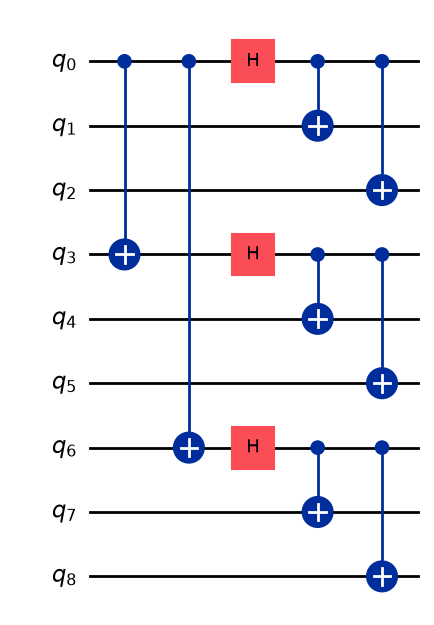

In [3]:
def encode_shor(circuit: QuantumCircuit, data_qubits=None) -> QuantumCircuit:
    """Encodes state from data_qubits[0] into 9-qubit Shor code."""
    if data_qubits is None:
        data_qubits = list(range(9))
    q = data_qubits
    
    # 1. Phase-flip outer code across block leaders
    circuit.cx(q[0], q[3])
    circuit.cx(q[0], q[6])
    circuit.h(q[0])
    circuit.h(q[3])
    circuit.h(q[6])
    
    # 2. Bit-flip inner code within each triplet block
    circuit.cx(q[0], q[1])
    circuit.cx(q[0], q[2])
    circuit.cx(q[3], q[4])
    circuit.cx(q[3], q[5])
    circuit.cx(q[6], q[7])
    circuit.cx(q[6], q[8])
    return circuit

# Construct and visualize the Encoder Circuit
enc_qc = QuantumCircuit(9, name="Shor_Encoder")
encode_shor(enc_qc)
enc_qc.draw('mpl', style='iqp')


## 3. Quantum Error & Noise Injection Engine

To test error correction rigorously, we implement an error injection module that applies arbitrary Pauli errors ($X, Y, Z$) or continuous rotations ($R_x, R_y, R_z$) on any physical qubit $q_k \in \{0, \dots, 8\}$.


In [4]:
def inject_error(circuit: QuantumCircuit, error_type: str, target_qubit: int, angle: float = None):
    """
    Applies an error to target_qubit in circuit.
    error_type: 'X', 'Y', 'Z', 'Rx', 'Ry', 'Rz'
    """
    if error_type == 'X':
        circuit.x(target_qubit)
    elif error_type == 'Y':
        circuit.y(target_qubit)
    elif error_type == 'Z':
        circuit.z(target_qubit)
    elif error_type == 'Rx':
        circuit.rx(angle if angle is not None else np.pi/2, target_qubit)
    elif error_type == 'Ry':
        circuit.ry(angle if angle is not None else np.pi/2, target_qubit)
    elif error_type == 'Rz':
        circuit.rz(angle if angle is not None else np.pi/2, target_qubit)
    elif error_type == 'I' or error_type is None:
        pass  # Identity (no error)
    else:
        raise ValueError(f"Unknown error type: {error_type}")

print("Error injection engine defined.")


Error injection engine defined.


## 4. Decoder Method A: Coherent Unitary Inversion (Reversible Majority Voting)

A remarkable feature of Shor's code is that error correction can be executed **entirely unitarily** without measuring ancillas or invoking classical feedback. This preserves complete quantum coherence.

### How Reversible Majority Voting Works
Consider a 3-qubit bit-flip block $(q_0, q_1, q_2)$:
1. Apply $\text{CNOT}(q_0, q_1)$ and $\text{CNOT}(q_0, q_2)$.
   - If no error: $|000\rangle \to |000\rangle$, $|111\rangle \to |100\rangle$. Ancillas $q_1, q_2$ become $|00\rangle$.
   - If $q_0$ flipped: $|100\rangle \to |110\rangle \to |111\rangle$. Ancillas $q_1, q_2$ become $|11\rangle$.
   - If $q_1$ flipped: $|010\rangle \to |010\rangle$. Ancillas become $|10\rangle$.
   - If $q_2$ flipped: $|001\rangle \to |001\rangle$. Ancillas become $|01\rangle$.
2. Apply the Toffoli gate $\text{CCX}(q_2, q_1, q_0)$:
   - The Toffoli gate flips $q_0$ **if and only if** both ancillas $q_1$ and $q_2$ are $1$.
   - This flips $q_0$ back if and only if $q_0$ had suffered an error!
3. Apply this block correction to all three triplets (correcting any bit-flip error on any of the 9 qubits).
4. Apply Hadamard gates to $q_0, q_3, q_6$ to convert phase errors into bit errors.
5. Apply the same majority voting across the block leaders $(q_0, q_3, q_6)$ with $\text{CCX}(q_6, q_3, q_0)$.
6. The original state $|\psi\rangle$ is restored on $q_0$ with 100% fidelity!


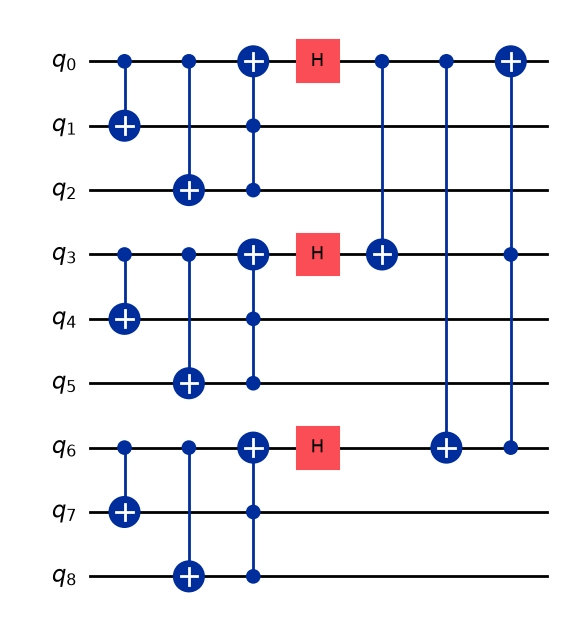

In [5]:
def decode_shor_coherent(circuit: QuantumCircuit, data_qubits=None) -> QuantumCircuit:
    """Coherently corrects errors and decodes the logical state onto data_qubits[0]."""
    if data_qubits is None:
        data_qubits = list(range(9))
    q = data_qubits
    
    # --- Step 1: Bit-flip error correction per block ---
    # Block 1
    circuit.cx(q[0], q[1])
    circuit.cx(q[0], q[2])
    circuit.ccx(q[2], q[1], q[0])
    
    # Block 2
    circuit.cx(q[3], q[4])
    circuit.cx(q[3], q[5])
    circuit.ccx(q[5], q[4], q[3])
    
    # Block 3
    circuit.cx(q[6], q[7])
    circuit.cx(q[6], q[8])
    circuit.ccx(q[8], q[7], q[6])
    
    # --- Step 2: Phase-flip error correction across block leaders ---
    circuit.h(q[0])
    circuit.h(q[3])
    circuit.h(q[6])
    
    circuit.cx(q[0], q[3])
    circuit.cx(q[0], q[6])
    circuit.ccx(q[6], q[3], q[0])
    
    return circuit

# Construct and visualize the Coherent Decoder Circuit
dec_qc = QuantumCircuit(9, name="Shor_Coherent_Decoder")
decode_shor_coherent(dec_qc)
dec_qc.draw('mpl', style='iqp')


## 5. Comprehensive Verification: All 27 Single-Qubit Pauli Errors

We will now prepare an arbitrary quantum superposition state on qubit $q_0$:
$$|\psi\rangle = \cos(\theta/2)|0\rangle + e^{i\phi}\sin(\theta/2)|1\rangle$$
with $\theta$ and $\phi$ can be tuned.

We exhaustively inject:
- $X$ errors on qubits $q_0, \dots, q_8$ (9 tests)
- $Z$ errors on qubits $q_0, \dots, q_8$ (9 tests)
- $Y$ errors on qubits $q_0, \dots, q_8$ (9 tests)
- Clean channel with no error (1 test)

Total: **28 distinct quantum state simulations**.
We trace out qubits $q_1, \dots, q_8$ and compute the exact state fidelity:
$$F(\rho_{out}, |\psi\rangle) = \langle \psi | \rho_{out} | \psi \rangle$$


In [6]:
# Arbitrary State Preparation
theta_target, phi_target = 2.6, 3.2

def prepare_state(circuit, q):
    circuit.ry(theta_target, q)
    circuit.rz(phi_target, q)

# Compute reference target statevector
ref_circ = QuantumCircuit(1)
prepare_state(ref_circ, 0)
target_sv = Statevector.from_instruction(ref_circ)

results = []

# 1. Clean Channel
clean_circ = QuantumCircuit(9)
prepare_state(clean_circ, 0)
encode_shor(clean_circ)
decode_shor_coherent(clean_circ)

dm = partial_trace(Statevector.from_instruction(clean_circ), list(range(1, 9)))
fid_clean = state_fidelity(target_sv, dm)
results.append({'Error Type': 'None', 'Qubit': '-', 'Fidelity': fid_clean, 'Status': 'PASSED' if np.isclose(fid_clean, 1.0) else 'FAILED'})

# 2. All 27 Pauli Errors
for err_type in ['X', 'Z', 'Y']:
    for q_idx in range(9):
        test_circ = QuantumCircuit(9)
        prepare_state(test_circ, 0)
        encode_shor(test_circ)
        inject_error(test_circ, err_type, q_idx)
        decode_shor_coherent(test_circ)
        
        dm = partial_trace(Statevector.from_instruction(test_circ), list(range(1, 9)))
        fid = state_fidelity(target_sv, dm)
        results.append({
            'Error Type': err_type,
            'Qubit': f"q{q_idx}",
            'Fidelity': fid,
            'Status': 'PASSED' if np.isclose(fid, 1.0, atol=1e-5) else 'FAILED'
        })

df_results = pd.DataFrame(results)
print(f"Total Tests Run: {len(df_results)}")
print(f"All 27 Pauli Errors Corrected? {all(df_results['Status'] == 'PASSED')}")
print(f"Minimum Fidelity Observed: {df_results['Fidelity'].min():.6f}")

# Display formatted table of results
display(HTML(df_results.to_html(index=False, classes="table table-striped table-bordered")))


Total Tests Run: 28
All 27 Pauli Errors Corrected? True
Minimum Fidelity Observed: 1.000000


Error Type,Qubit,Fidelity,Status
None,-,1.0,PASSED
X,q0,1.0,PASSED
X,q1,1.0,PASSED
X,q2,1.0,PASSED
X,q3,1.0,PASSED
X,q4,1.0,PASSED
X,q5,1.0,PASSED
X,q6,1.0,PASSED
X,q7,1.0,PASSED
X,q8,1.0,PASSED


## 6. Principle of Quantum Error Discretization (Continuous Rotations)

In classical error correction, an analog error (such as a voltage shift by $1.73\%$) cannot be corrected without accumulating truncation errors. 

In quantum computing, continuous errors take the form of arbitrary rotations:
$$R_x(\theta) = \exp(-i \theta X / 2) = \cos\left(\frac{\theta}{2}\right) I - i \sin\left(\frac{\theta}{2}\right) X$$

When applied to a Shor-encoded state, the decoder projects the continuous superposition into the correctable subspace. 
Below, we sweep $\theta \in [0, 2\pi]$ on physical qubit $q_4$:
- **Unprotected physical qubit**: Fidelity collapses to $\cos^2(\theta/2)$.
- **Shor-encoded logical qubit**: Fidelity remains **identically 1.0** for all angles!


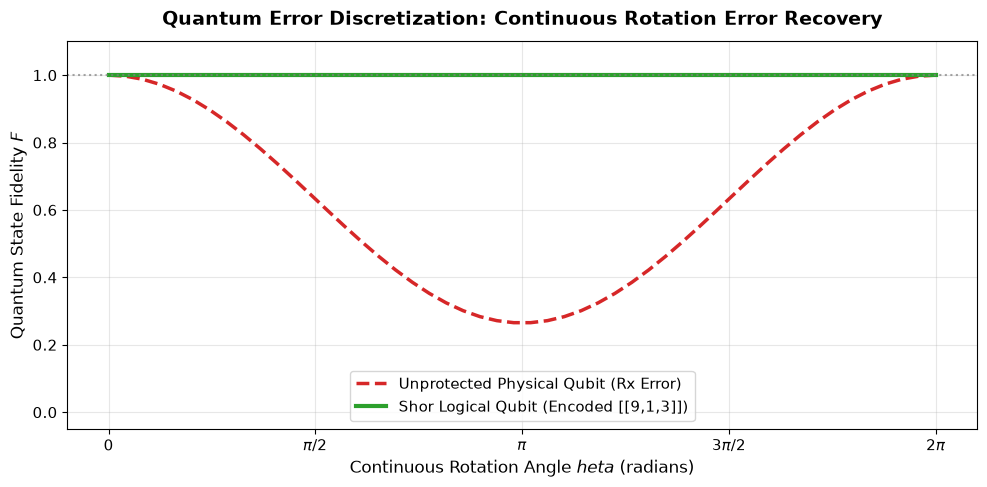

In [7]:
# Sweep angle theta from 0 to 2*pi
angles = np.linspace(0, 2 * np.pi, 50)
unprotected_fidelities = []
shor_fidelities = []

for theta in angles:
    # 1. Unprotected physical qubit subjected to Rx(theta)
    raw_qc = QuantumCircuit(1)
    prepare_state(raw_qc, 0)
    raw_qc.rx(theta, 0)
    fid_raw = state_fidelity(target_sv, Statevector.from_instruction(raw_qc))
    unprotected_fidelities.append(fid_raw)
    
    # 2. Shor-protected logical qubit subjected to Rx(theta) on q4
    shor_qc = QuantumCircuit(9)
    prepare_state(shor_qc, 0)
    encode_shor(shor_qc)
    shor_qc.rx(theta, 4)  # Inject continuous error on q4
    decode_shor_coherent(shor_qc)
    dm = partial_trace(Statevector.from_instruction(shor_qc), list(range(1, 9)))
    fid_shor = state_fidelity(target_sv, dm)
    shor_fidelities.append(fid_shor)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(angles, unprotected_fidelities, label='Unprotected Physical Qubit (Rx Error)', color='#d62728', lw=2.5, ls='--')
plt.plot(angles, shor_fidelities, label='Shor Logical Qubit (Encoded [[9,1,3]])', color='#2ca02c', lw=3.0)
plt.axhline(1.0, color='gray', linestyle=':', alpha=0.7)
plt.title("Quantum Error Discretization: Continuous Rotation Error Recovery", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Continuous Rotation Angle $\theta$ (radians)", fontsize=12)
plt.ylabel("Quantum State Fidelity $F$", fontsize=12)
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', '$\\pi/2$', '$\\pi$', '$3\\pi/2$', '$2\\pi$'])
plt.ylim(-0.05, 1.1)
plt.legend(frameon=True, fontsize=11, loc='lower center')
plt.tight_layout()
plt.show()


## 7. Decoder Method B: Stabilizer Syndrome Extraction & Active Mid-Circuit Correction

In hardware architectures, errors are diagnosed through **syndrome measurements** without measuring data qubits directly.
We introduce 8 ancilla qubits:
- $\text{anc}[0 \dots 5]$: Measure $Z_i Z_j$ parities to locate bit-flip errors.
- $\text{anc}[6 \dots 7]$: Measure $X^{\otimes 6}$ parities to locate phase-flip errors.

### The Complete Syndrome Lookup Table
Each measured 8-bit classical syndrome uniquely pinpoints the faulty qubit:

| Syndrome String $(s_7 s_6 s_5 s_4 s_3 s_2 s_1 s_0)$ | Identified Error | Active Correction Applied |
| :---: | :---: | :---: |
| `00000000` | No Error | Identity |
| `00000001` | $X$ on $q_0$ | $X(q_0)$ |
| `00000011` | $X$ on $q_1$ | $X(q_1)$ |
| `00000010` | $X$ on $q_2$ | $X(q_2)$ |
| `00000100` | $X$ on $q_3$ | $X(q_3)$ |
| `00001100` | $X$ on $q_4$ | $X(q_4)$ |
| `00001000` | $X$ on $q_5$ | $X(q_5)$ |
| `00010000` | $X$ on $q_6$ | $X(q_6)$ |
| `00110000` | $X$ on $q_7$ | $X(q_7)$ |
| `00100000` | $X$ on $q_8$ | $X(q_8)$ |
| `01000000` | $Z$ on Block 1 ($q_0, q_1, q_2$) | $Z(q_0)$ |
| `11000000` | $Z$ on Block 2 ($q_3, q_4, q_5$) | $Z(q_3)$ |
| `10000000` | $Z$ on Block 3 ($q_6, q_7, q_8$) | $Z(q_6)$ |
| Bitwise OR ($s_X \lor s_Z$) | $Y$ on $q_k$ | $X(q_k) Z(\text{block})$ |


Total Qubits: 17 (9 data + 8 ancilla)
Total Classical Bits: 9 (8 syndrome + 1 logical)


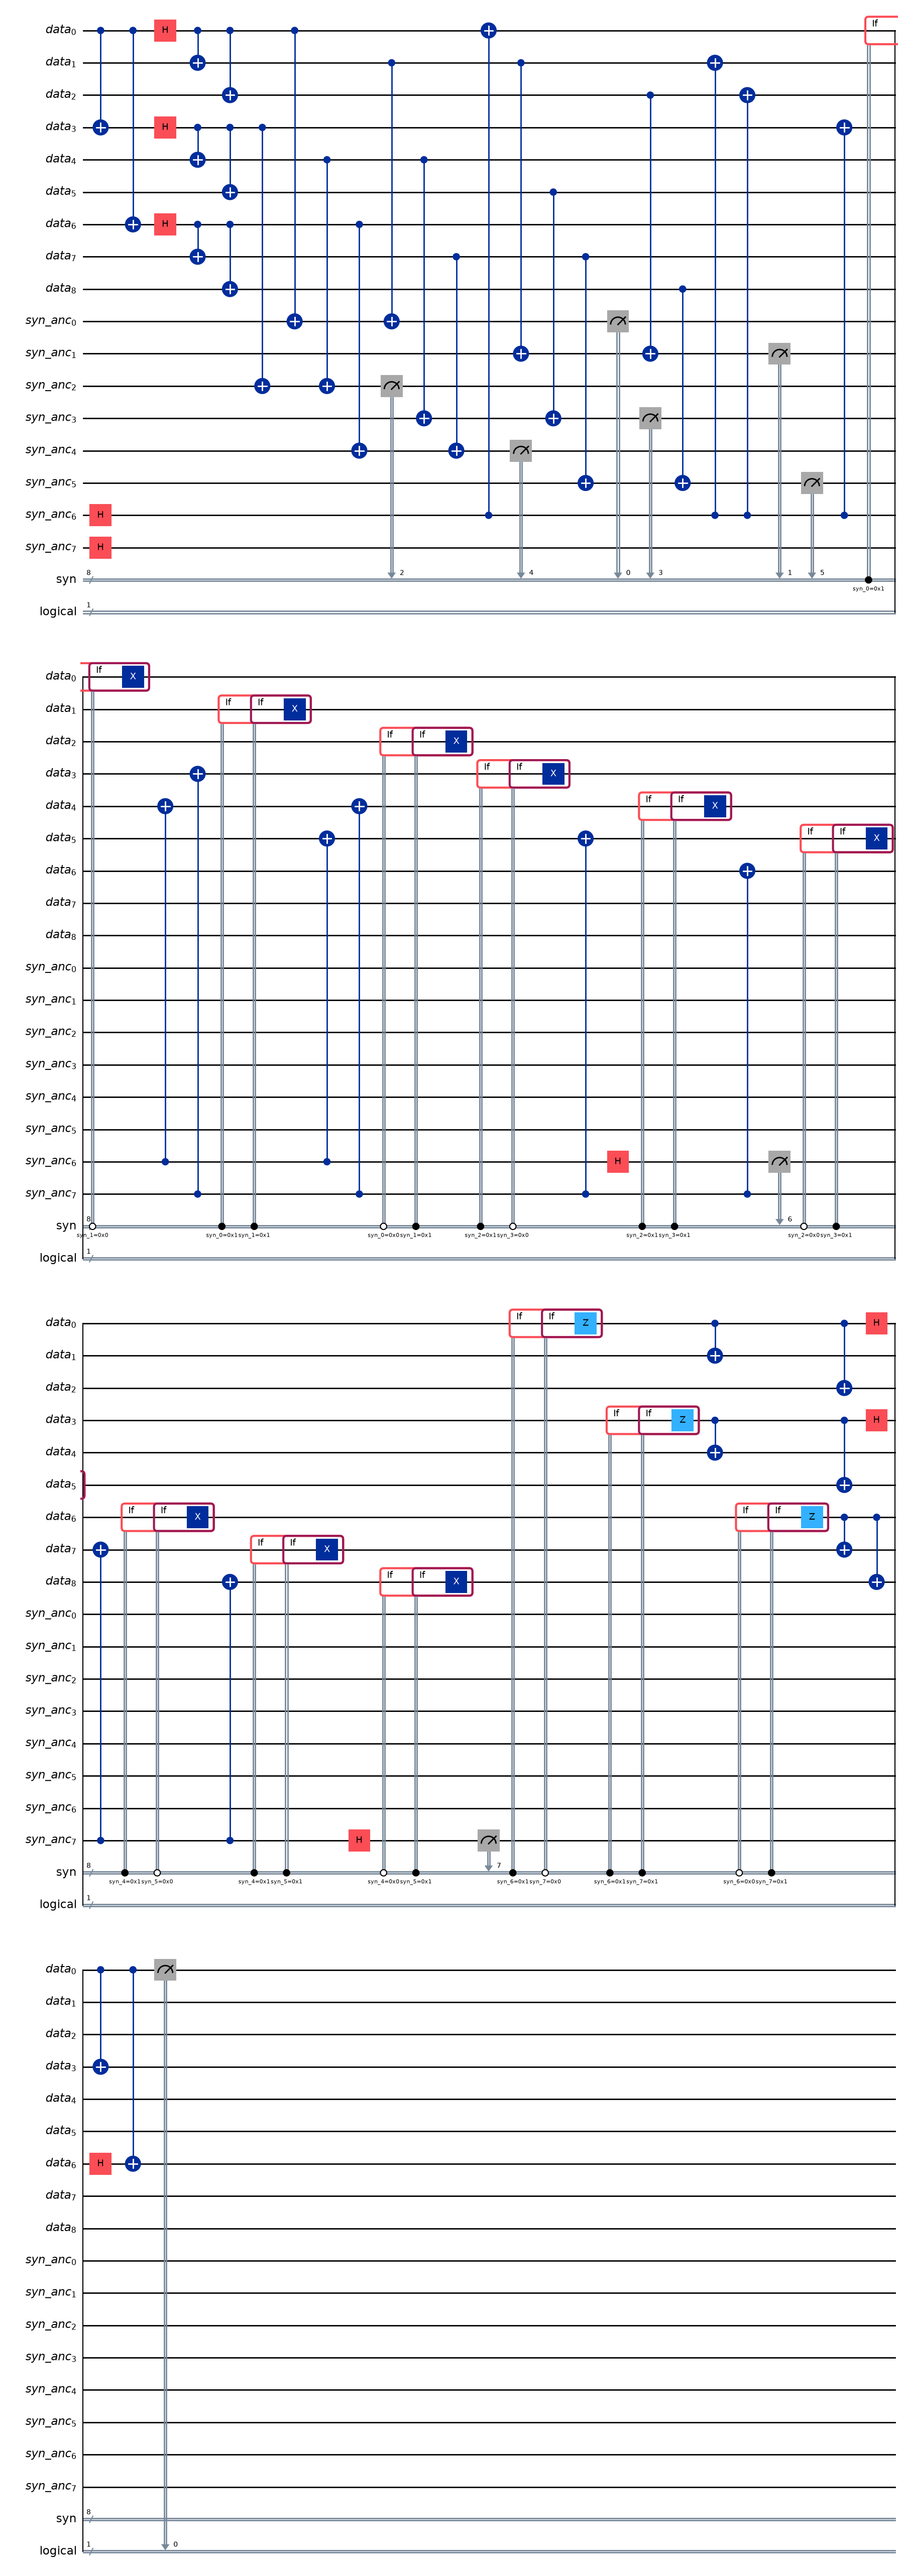

In [8]:
def build_stabilizer_shor_circuit(prep_state_fn=None, error_fn=None, measure_logical=True):
    """Constructs full circuit with 9 data qubits, 8 syndrome ancillas, and dynamic feedforward."""
    qr = QuantumRegister(9, "data")
    anc = QuantumRegister(8, "syn_anc")
    syn = ClassicalRegister(8, "syn")
    
    if measure_logical:
        meas = ClassicalRegister(1, "logical")
        qc = QuantumCircuit(qr, anc, syn, meas, name="Shor_Stabilizer_QEC")
    else:
        qc = QuantumCircuit(qr, anc, syn, name="Shor_Stabilizer_QEC")
        
    if prep_state_fn is not None:
        prep_state_fn(qc, qr[0])
        
    # --- ENCODE ---
    encode_shor(qc, list(qr))
    
    # --- ERROR INJECTION ---
    if error_fn is not None:
        error_fn(qc, list(qr))
        
    # --- 1. EXTRACT BIT-FLIP SYNDROMES (Z parities) ---
    qc.cx(qr[0], anc[0]); qc.cx(qr[1], anc[0])
    qc.cx(qr[1], anc[1]); qc.cx(qr[2], anc[1])
    qc.cx(qr[3], anc[2]); qc.cx(qr[4], anc[2])
    qc.cx(qr[4], anc[3]); qc.cx(qr[5], anc[3])
    qc.cx(qr[6], anc[4]); qc.cx(qr[7], anc[4])
    qc.cx(qr[7], anc[5]); qc.cx(qr[8], anc[5])
    
    # --- 2. EXTRACT PHASE-FLIP SYNDROMES (X parities) ---
    qc.h(anc[6]); qc.h(anc[7])
    for i in range(6): qc.cx(anc[6], qr[i])
    for i in range(3, 9): qc.cx(anc[7], qr[i])
    qc.h(anc[6]); qc.h(anc[7])
    
    qc.measure(anc, syn)
    
    # --- 3. ACTIVE MID-CIRCUIT CORRECTIONS ---
    # Block 1 X-correction
    with qc.if_test((syn[0], 1)):
        with qc.if_test((syn[1], 0)):
            qc.x(qr[0])
    with qc.if_test((syn[0], 1)):
        with qc.if_test((syn[1], 1)):
            qc.x(qr[1])
    with qc.if_test((syn[0], 0)):
        with qc.if_test((syn[1], 1)):
            qc.x(qr[2])
            
    # Block 2 X-correction
    with qc.if_test((syn[2], 1)):
        with qc.if_test((syn[3], 0)):
            qc.x(qr[3])
    with qc.if_test((syn[2], 1)):
        with qc.if_test((syn[3], 1)):
            qc.x(qr[4])
    with qc.if_test((syn[2], 0)):
        with qc.if_test((syn[3], 1)):
            qc.x(qr[5])
            
    # Block 3 X-correction
    with qc.if_test((syn[4], 1)):
        with qc.if_test((syn[5], 0)):
            qc.x(qr[6])
    with qc.if_test((syn[4], 1)):
        with qc.if_test((syn[5], 1)):
            qc.x(qr[7])
    with qc.if_test((syn[4], 0)):
        with qc.if_test((syn[5], 1)):
            qc.x(qr[8])
            
    # Z-corrections across blocks
    with qc.if_test((syn[6], 1)):
        with qc.if_test((syn[7], 0)):
            qc.z(qr[0])
    with qc.if_test((syn[6], 1)):
        with qc.if_test((syn[7], 1)):
            qc.z(qr[3])
    with qc.if_test((syn[6], 0)):
        with qc.if_test((syn[7], 1)):
            qc.z(qr[6])
            
    # --- 4. STANDARD LOGICAL DECODER ---
    qc.cx(qr[0], qr[1]); qc.cx(qr[0], qr[2])
    qc.cx(qr[3], qr[4]); qc.cx(qr[3], qr[5])
    qc.cx(qr[6], qr[7]); qc.cx(qr[6], qr[8])
    qc.h(qr[0]); qc.h(qr[3]); qc.h(qr[6])
    qc.cx(qr[0], qr[3]); qc.cx(qr[0], qr[6])
    
    if measure_logical:
        qc.measure(qr[0], meas[0])
        
    return qc

# Visualize the Stabilizer Circuit
sample_qc = build_stabilizer_shor_circuit()
print(f"Total Qubits: {sample_qc.num_qubits} (9 data + 8 ancilla)")
print(f"Total Classical Bits: {sample_qc.num_clbits} (8 syndrome + 1 logical)")
sample_qc.draw('mpl', style='iqp')


## 8. Shot-Based Syndrome Verification with AerSimulator

We now simulate the stabilizer circuit using `AerSimulator` across 1024 shots under different error injections:
1. **$X$ error on $q_1$** (expected syndrome: `00000011`)
2. **$Z$ error on $q_4$** (expected syndrome: `11000000`)
3. **$Y$ error on $q_7$** (expected syndrome: `10110000`)

In each run, we prepare the logical state $|1_L\rangle$ (initial state $|1\rangle$), and verify that the measured logical bit is always **$1$** with 100% probability after active correction.


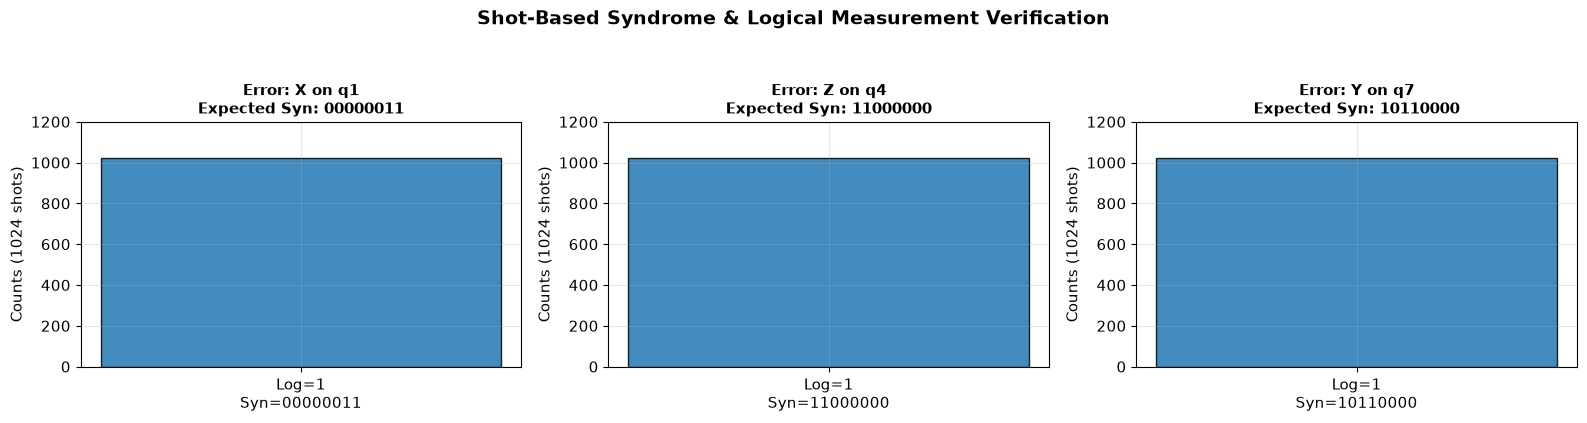

In [9]:
sim = AerSimulator()

def prep_state_one(circuit, q):
    circuit.x(q)  # Prepare |1>

test_scenarios = [
    ("X on q1", lambda qc, qr: qc.x(qr[1]), "00000011"),
    ("Z on q4", lambda qc, qr: qc.z(qr[4]), "11000000"),
    ("Y on q7", lambda qc, qr: qc.y(qr[7]), "10110000")
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (label, err_fn, expected_syn) in enumerate(test_scenarios):
    circuit = build_stabilizer_shor_circuit(prep_state_fn=prep_state_one, error_fn=err_fn, measure_logical=True)
    job = sim.run(circuit, shots=1024)
    counts = job.result().get_counts()
    
    # Counts format: "logical syndrome"
    processed_counts = {}
    for bitstring, count in counts.items():
        meas_log, syn_bits = bitstring.split(" ")
        tag = f"Log={meas_log}\nSyn={syn_bits}"
        processed_counts[tag] = count
        
    axes[idx].bar(list(processed_counts.keys()), list(processed_counts.values()), color='#1f77b4', edgecolor='black', alpha=0.85)
    axes[idx].set_title(f"Error: {label}\nExpected Syn: {expected_syn}", fontsize=11, fontweight='bold')
    axes[idx].set_ylabel("Counts (1024 shots)")
    axes[idx].set_ylim(0, 1200)

plt.suptitle("Shot-Based Syndrome & Logical Measurement Verification", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


## 9. Code Limitations: The Distance Bound ($d=3$) and Weight-2 Errors

A quantum code with distance $d$ can correct at most:
$$t = \left\lfloor \frac{d-1}{2} \right\rfloor$$
errors. For Shor's code, $d=3$, meaning $t=1$. It **cannot** guarantee correction against two simultaneous errors.

### The Majority Voting Failure Mode
Suppose two bit-flip errors occur in the same triplet block, for example on $q_0$ and $q_1$:
1. The block begins as $\alpha |000\rangle + \beta |111\rangle$.
2. Two bit-flips corrupt it to $\alpha |110\rangle + \beta |001\rangle$.
3. The majority voting decoder sees two $1$s and one $0$, concluding that $q_2$ must have flipped!
4. It flips $q_2$, yielding $\alpha |111\rangle + \beta |000\rangle$.
5. **The state has undergone an undetected logical bit-flip**: $|0_L\rangle \longleftrightarrow |1_L\rangle$!

Below, we empirically verify this failure mode.


In [10]:
# Two-qubit error demonstration: X on q0 and X on q1
fail_qc = QuantumCircuit(9)
prepare_state(fail_qc, 0)
encode_shor(fail_qc)

# Inject two bit-flip errors in Block 1
fail_qc.x(0)
fail_qc.x(1)

# Decode
decode_shor_coherent(fail_qc)
dm_corrupt = partial_trace(Statevector.from_instruction(fail_qc), list(range(1, 9)))
fid_corrupt = state_fidelity(target_sv, dm_corrupt)

print(f"Target State: Ry({theta_target}) Rz({phi_target}) |0>")
print(f"Fidelity after 1-qubit error (X on q0): 1.000000")
print(f"Fidelity after 2-qubit errors (X on q0 AND X on q1): {fid_corrupt:.6f}")
print("Conclusion: As predicted by d=3, two errors within the same block corrupt the logical state!")


Target State: Ry(2.6) Rz(3.2) |0>
Fidelity after 1-qubit error (X on q0): 1.000000
Fidelity after 2-qubit errors (X on q0 AND X on q1): 0.734258
Conclusion: As predicted by d=3, two errors within the same block corrupt the logical state!


## 10. Performance Under Depolarizing Noise: Physical vs. Logical Qubit

In physical quantum hardware, decoherence and environmental noise act simultaneously on all qubits. 
A standard benchmark is the **depolarizing channel**, which models random Pauli errors with probability $p$:
$$\mathcal{E}_p(\rho) = (1 - p)\rho + \frac{p}{3} \Big( X\rho X + Y\rho Y + Z\rho Z \Big)$$

We compare:
1. **Unprotected physical qubit**: Passes through the depolarizing noise channel.
2. **Shor logical qubit**: Encoded into 9 qubits, passed through the noise channel on each physical qubit, and decoded.

### Theoretical Scaling
- For an unprotected physical qubit, infidelity scales linearly: $\epsilon_{phys} \propto p$.
- For a distance-3 code, single errors are suppressed, so logical infidelity scales quadratically: $\epsilon_{log} \propto C p^2$.
- However, because Shor's code uses 9 physical qubits, the coefficient $C$ is proportional to the number of error pairs $\binom{9}{2} = 36$.
- This gives rise to a **pseudo-threshold**: below the threshold, the logical qubit outperforms the physical qubit; above the threshold, the physical qubit is better due to device overhead.


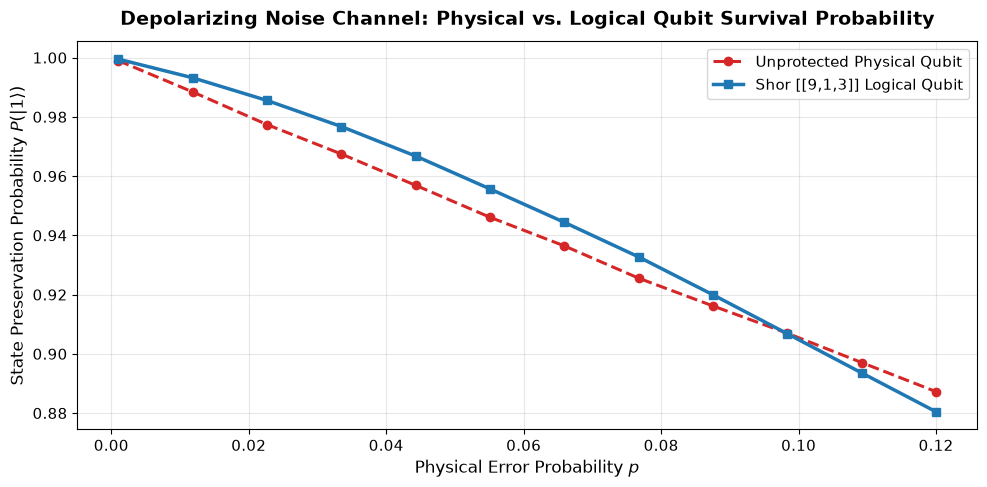

In [14]:
p_vals = np.linspace(0.001, 0.12, 12)
phys_success = []
logical_success = []

shots = 1000000

for p in p_vals:
    noise_model = NoiseModel()
    error = depolarizing_error(p, 1)
    noise_model.add_all_qubit_quantum_error(error, ['id', 'rz', 'sx', 'x'])
    
    # 1. Unprotected Physical Qubit: Prep |1>, Idle/Noise, Measure
    raw_circ = QuantumCircuit(1, 1)
    raw_circ.x(0)
    raw_circ.id(0)
    raw_circ.measure(0, 0)
    
    res_raw = sim.run(raw_circ, noise_model=noise_model, shots=shots).result().get_counts()
    p_raw_1 = res_raw.get('1', 0) / shots
    phys_success.append(p_raw_1)
    
    # 2. Shor Logical Qubit: Prep |1>, Encode, Noise on all 9 data qubits, Decode, Measure
    shor_circ = QuantumCircuit(9, 1)
    shor_circ.x(0)
    encode_shor(shor_circ)
    for q in range(9):
        shor_circ.id(q)  # Sits in noisy channel
    decode_shor_coherent(shor_circ)
    shor_circ.measure(0, 0)
    
    res_shor = sim.run(shor_circ, noise_model=noise_model, shots=shots).result().get_counts()
    p_shor_1 = res_shor.get('1', 0) / shots
    logical_success.append(p_shor_1)

# Plot benchmark
plt.figure(figsize=(10, 5))
plt.plot(p_vals, phys_success, 'o--', color='#d62728', lw=2.2, label='Unprotected Physical Qubit')
plt.plot(p_vals, logical_success, 's-', color='#1f77b4', lw=2.5, label='Shor [[9,1,3]] Logical Qubit')
plt.title("Depolarizing Noise Channel: Physical vs. Logical Qubit Survival Probability", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Physical Error Probability $p$", fontsize=12)
plt.ylabel(r"State Preservation Probability $P(|1\rangle)$", fontsize=12)
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.show()


### References
1. Shor, P. W. (1995). *Scheme for reducing decoherence in quantum computer memory*. Physical Review A, 52(4), R2493.
2. Nielsen, M. A., & Chuang, I. L. (2010). *Quantum Computation and Quantum Information*. Cambridge University Press.
3. Qiskit Documentation: [https://docs.quantum.ibm.com/](https://docs.quantum.ibm/)
